### Imports

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json
from typing import Dict, List, Tuple, Callable

In [45]:
import sys
sys.path.append("..")

from scripts.eda import basic_summary, plot_series, plot_distribution, plot_rolling_statistics, plot_acf_series, plot_pacf_series, plot_hourly_mean, plot_dayofweek_mean, plot_boxplot_by_hour, plot_boxplot_by_dayofweek, adf_test, compute_anomaly_statistics, plot_lag, fast_fourier_transform_estimation

### Data Analysis Pipeline

The identified files will be loaded below, and each will undergo a basic time series analysis, along with some relevant plotting. This file will conclude with a brief discussion of observations and potential modeling constraints.

Files to load:
- **CPU_UTIL_1** - ec2_cpu_utilization_5f5533.csv
- **DISK_WRITE_1** - ec2_disk_write_bytes_c0d644.csv
- **NETWORK_IN_1** - ec2_network_in_5abac7.csv
- **REQUEST_COUNT** - elb_request_count_8c0756.csv

Note that in all cases, the data is structured with time-stamps and a singular value, meaning that this is not a **multi-variate time-series analysis**.

In [46]:
files_map = {
    'CPU_UTIL_1': 'ec2_cpu_utilization_5f5533.csv',
    'DISK_WRITE_': 'ec2_disk_write_bytes_c0d644.csv',
    'NETWORK_IN_1': 'ec2_network_in_5abac7.csv',
    'REQUEST_COUNT': 'elb_request_count_8c0756.csv'
}

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')

In [47]:
with open(os.path.join(DATA_DIR, 'combined_windows.json')) as file:
    windows_data = json.load(file)

anomaly_windows_map: Dict = {
    key: [
        (pd.Timestamp(start), pd.Timestamp(end))
        for start, end in windows_data.get(f'realAWSCloudwatch/{file}', [])
    ]
    for key, file in files_map.items()
}

dfs_map: Dict[str, Tuple[pd.DataFrame, List[Tuple[pd.Timestamp, pd.Timestamp]]]] = {}

for key, file in files_map.items():
    df = pd.read_csv(os.path.join(DATA_DIR, files_map[key]))
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    dfs_map[key] = (df, anomaly_windows_map[key])

In [48]:
def print_banner(dataset_name: str) -> None:
    print('#' * 150)
    print(f'Dataset {dataset_name} Analysis')
    print('#' * 150)

## CPU Utilization Data Analysis

### Basic Summary, Visualization, Data Distribution, and Anomaly Analysis

In [49]:
def eda_1(dataset_name: str, df: pd.DataFrame, anomaly_windows: List[Tuple[pd.Timestamp, pd.Timestamp]]) -> None:
    print_banner(dataset_name=dataset_name)
    basic_summary(df=df, should_print=True)
    plot_series(df=df, anomaly_windows=anomaly_windows, title=f'Time Series Plot (With Anomalies) for {dataset_name}')
    plot_distribution(df=df, bins=int(np.clip(np.sqrt(len(df)), 10, 60)), title=f'Distribution Plots for {dataset_name}')
    plot_lag(df=df, anomaly_windows=anomaly_windows, lags=[1, 3, 6, 12, 48, 72, 144, 288])
    compute_anomaly_statistics(df=df, anomaly_windows=anomaly_windows, timestamp_col='timestamp', should_print=True)


######################################################################################################################################################
Dataset CPU_UTIL_1 Analysis
######################################################################################################################################################
Metric                  Value
----------------------  ---------------------------------------
n_rows                  4032
start_time              2014-02-14 14:27:00
end_time                2014-02-28 14:22:00
median_interval         0 days 00:05:00
mode_interval           0   0 days 00:05:00
                        Name: timestamp, dtype: timedelta64[us]
n_missing_timestamps    0
n_duplicate_timestamps  0
min_value               34.766
max_value               68.092
mean_value              43.11037160218254
std_value               4.303564641024769


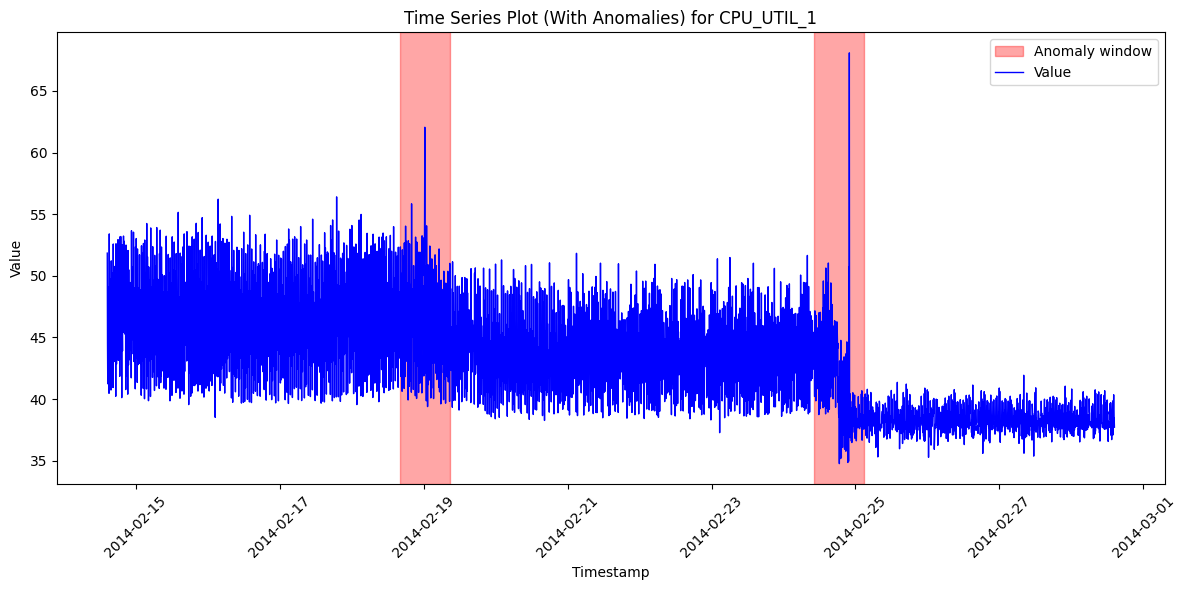

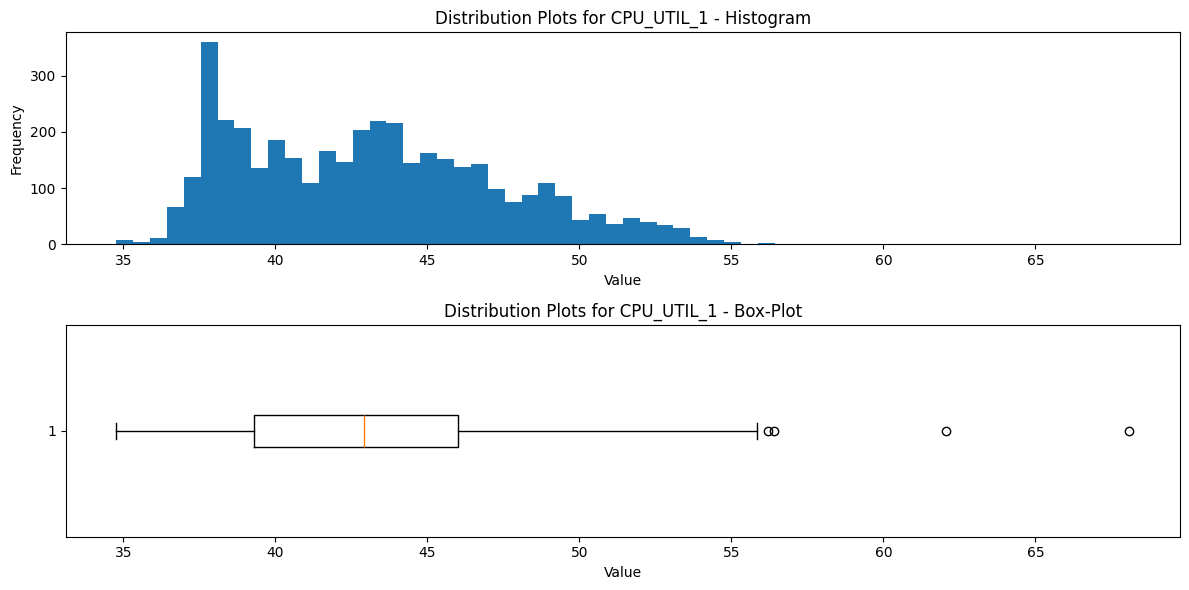

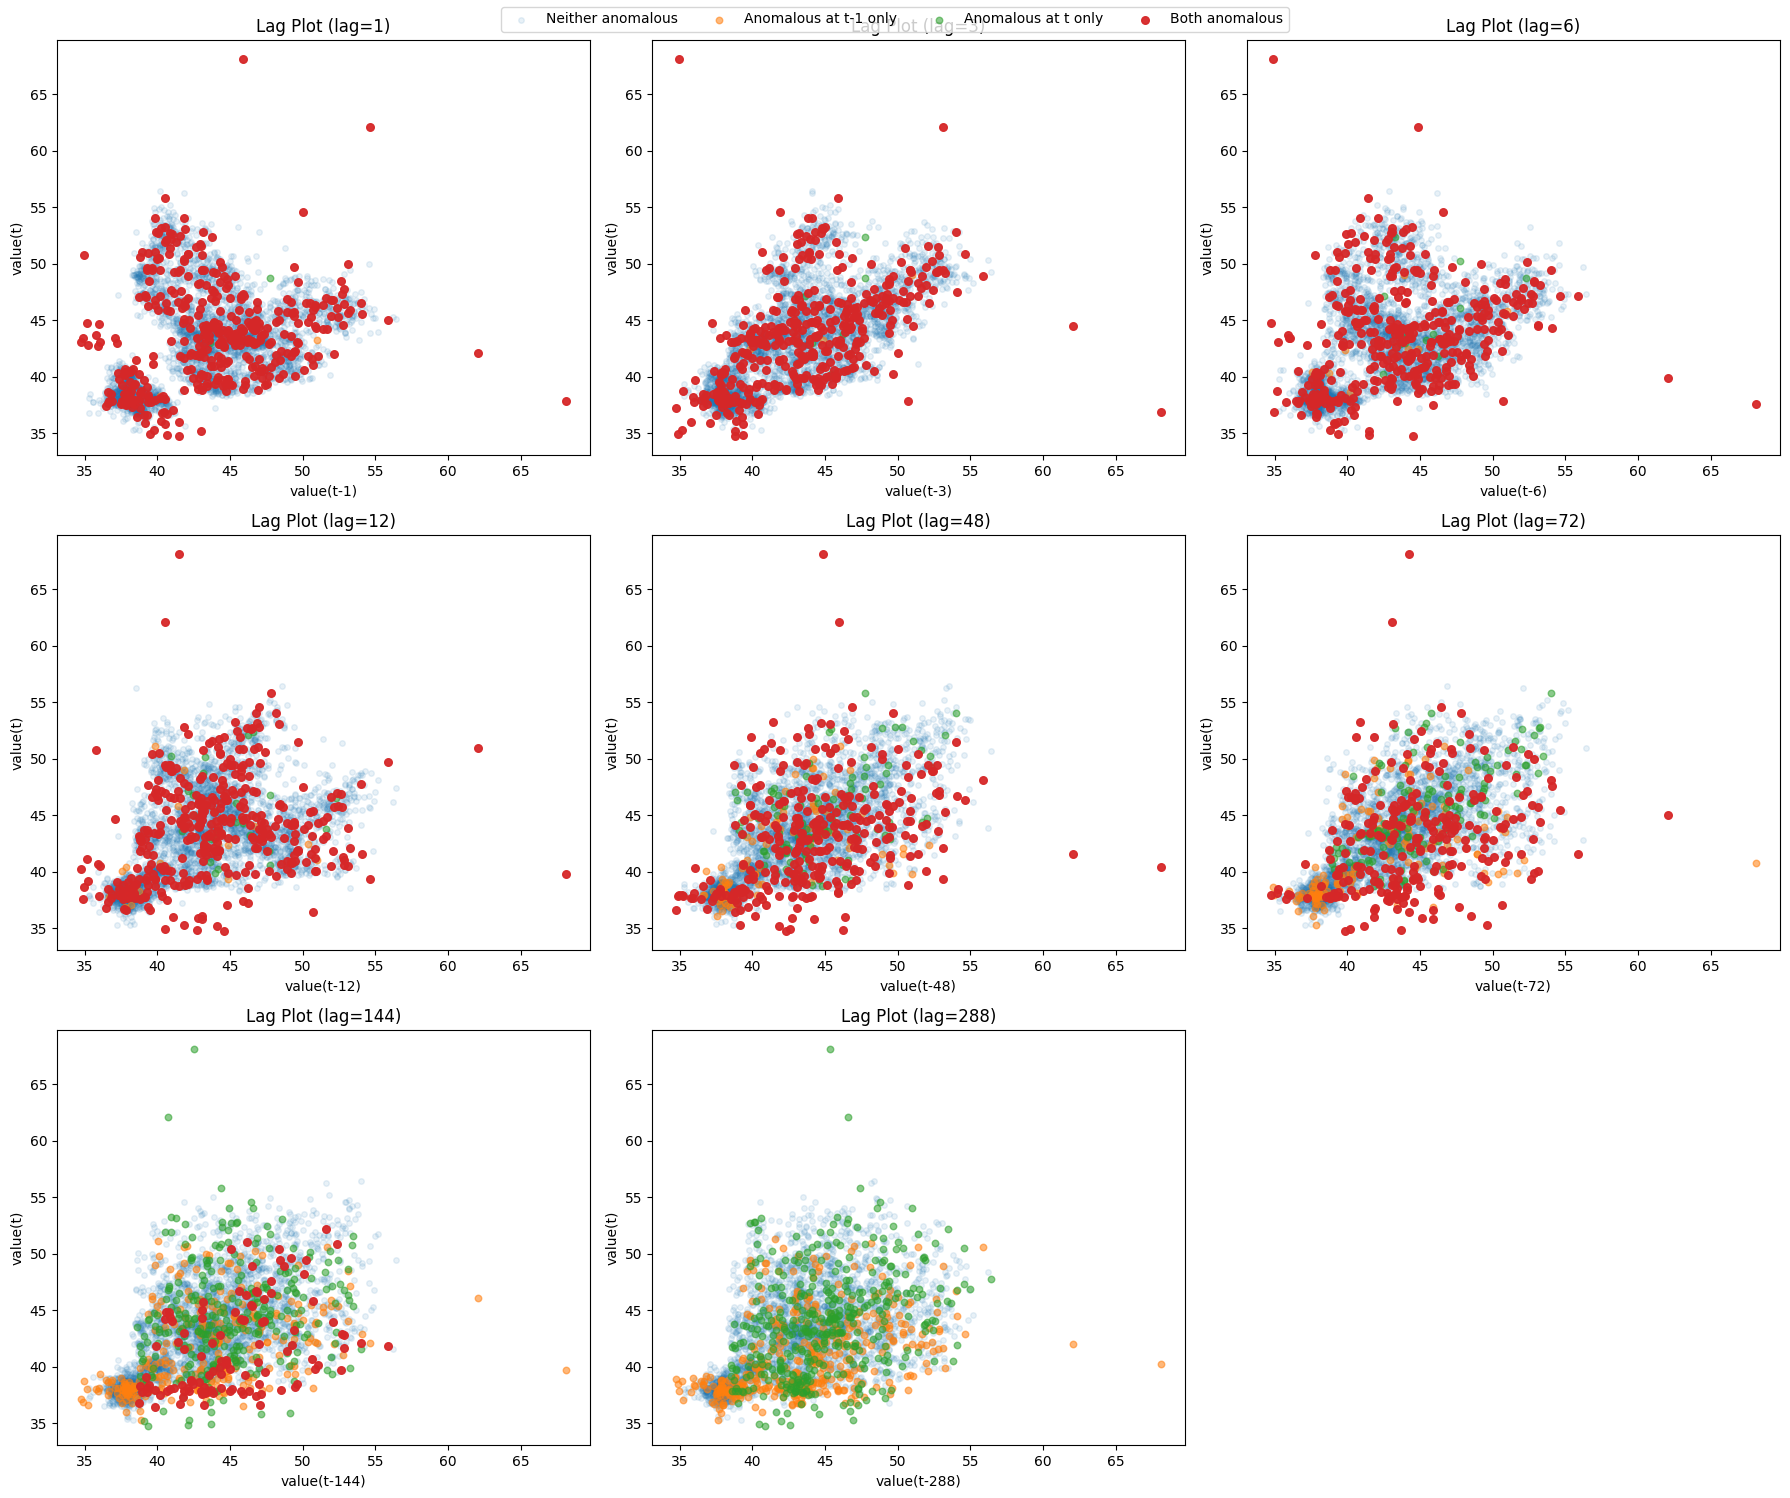

Property                  Value
------------------------  -------------------
n_anomaly_windows         2
total_anomaly_duration    1 days 09:20:00
avg_anomaly_duration      0 days 16:40:00
n_points                  4032
n_anomalous_points        402
anomalous_point_fraction  0.09970238095238096


In [50]:
dataset_name = 'CPU_UTIL_1'
dataframe, anomaly_windows = dfs_map[dataset_name]

eda_1(dataset_name=dataset_name, df=dataframe, anomaly_windows=anomaly_windows)

The CPU Utilization data is sampled every five minutes, and has a range (34.766, 68.092) with mean value 43.11037160218254. Overall, the data appears to be relatively consistent around the mean, but the anomaly windows are placed upon areas where outliers are detected, illustrated as well in the Box-Plot. It cannot be claimed that the data is Normally distributed based on the Histogram, however, further testing would be required to conclude this definitively. An interesting element of this data is that the period of transition from the operating mean CPU utilization of ~45 falls dramatically to ~39 around 2014-02-25. This may be due to organizational changes or a systematic change in the usage of the system, however, this period is marked as an anomaly.

Characteristics:
- Relatively stable value range albeit for outliers.
- Outliers are flagged as anomalous in this case.
- Change in data distribution over time (2014-02-25) must be accommodated.
- Recent history is more informative for the current value, as shown by the lag plots, with dependence reducing in a non-random manner.
- Anomalous points do not form a completely separate cluster, meaning it is not trivial to separate them from value-pairs alone.
- Anomaly windows are long, average duration of 16 hours suggests that we are interested in a large period of abnormal activity in comparison to the sampling interval.

### Rolling Statistics

In [51]:
def eda_2(dataset_name: str, df: pd.DataFrame, windows: List[int]) -> None:
    print_banner(dataset_name=dataset_name)
    for window in windows:
        plot_rolling_statistics(df=df, window=window, title=f'Rolling Statistics (Window = {window} hours) Plot for {dataset_name}')
    plot_hourly_mean(df=df, title=f'Average Hourly Value for {dataset_name}')
    plot_dayofweek_mean(df=df, title=f'Average Value by Day for {dataset_name}')
    plot_boxplot_by_hour(df=df, title=f'Hourly Box-Plot for {dataset_name}')
    plot_boxplot_by_dayofweek(df=df, title=f'Day-of-Week Box-Plot for {dataset_name}')


######################################################################################################################################################
Dataset CPU_UTIL_1 Analysis
######################################################################################################################################################


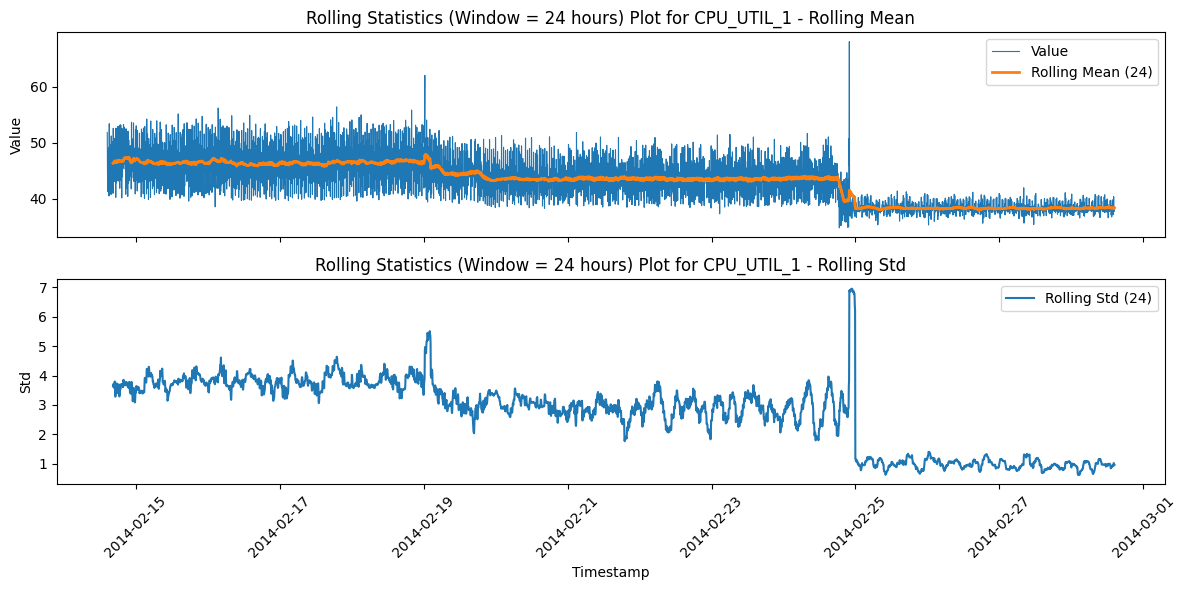

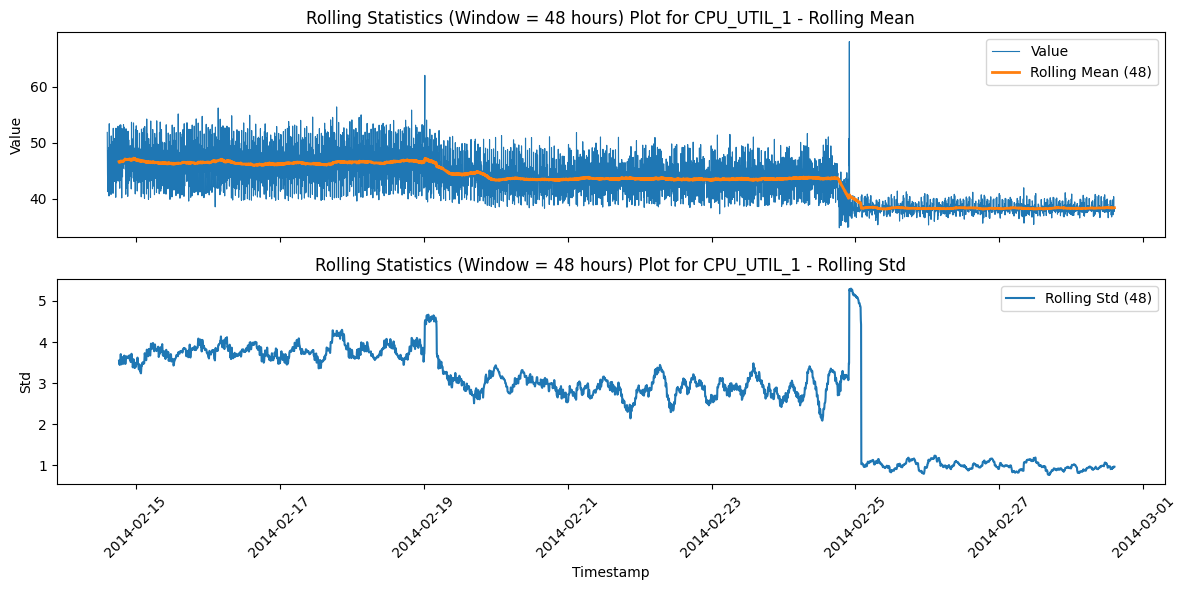

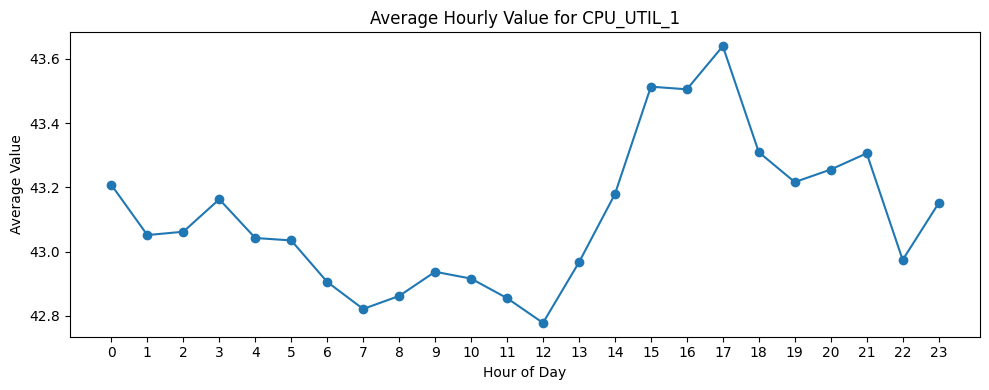

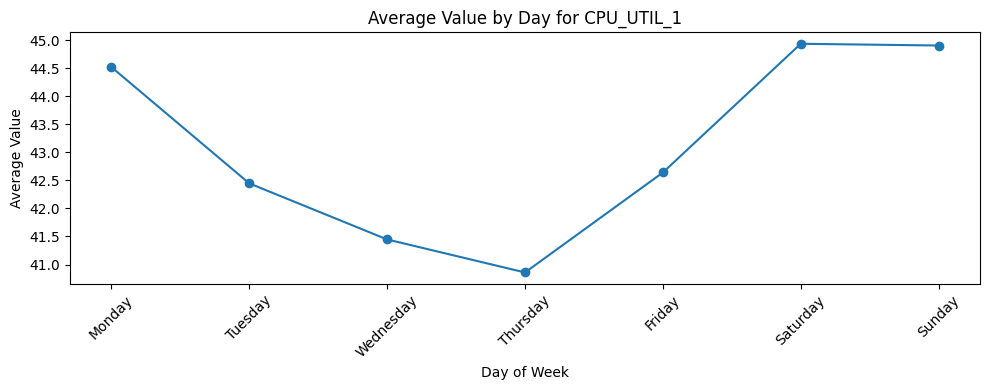

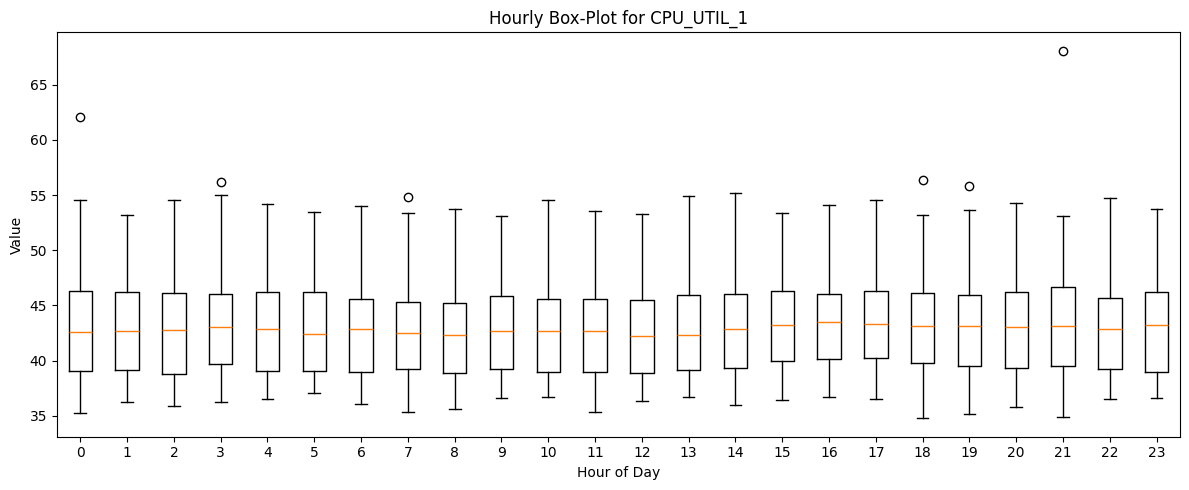

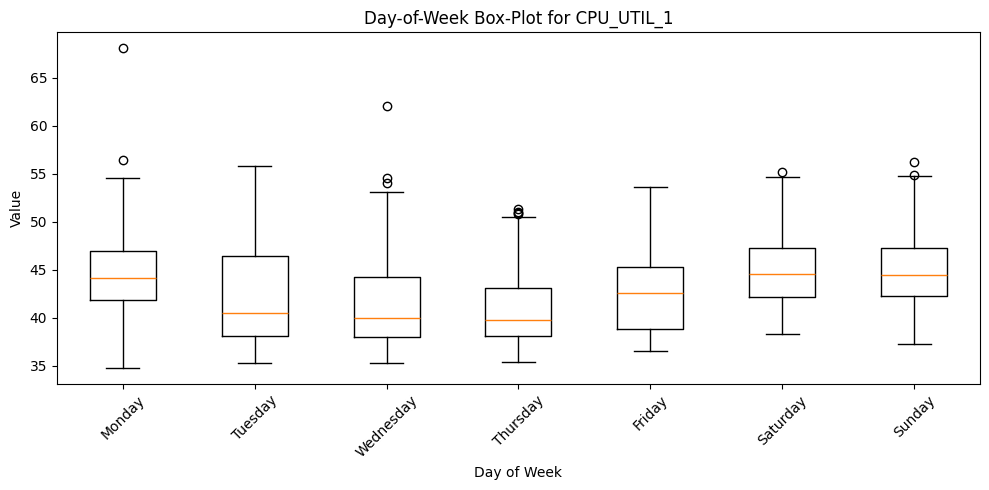

In [52]:
eda_2(dataset_name=dataset_name, df=dataframe, windows=[24, 48])

TODO: Could benefit from splitting the series and plotting the above for the two different operational levels.

Characteristics:
- 2014-02-25 seems to be a systematic change in operating level, not an isolated anomaly.
- The CPU utilization becomes less variable after the shift in operating level.
- Few additional spikes but not enough to be flagged as anomalous.
- Mild time-of-day structure (higher usage in the evenings), but not very interpretable as we do not know the business context.
- Clearer day-of-week effect, with lower averages during the week and higher averages on Monday and the weekend.

## ACF and PACF

In [53]:
def eda_3(dataset_name: str, df: pd.DataFrame, acf_lags: int, pacf_lags: int) -> None:
    print_banner(dataset_name=dataset_name)
    plot_acf_series(df=df, lags=acf_lags, title=f'ACF Plot for {dataset_name}')
    plot_pacf_series(df=df, lags=pacf_lags, title=f'PACF Plot for {dataset_name}')

Since the data is collected every five minutes, we should select a reasonable number of lags for ACF/PACF. For ACF, we will inspect 288 lags, which is 24 hours. For PACF, which tends to become noisy, we will settle at 48 lags, which is 4 hours.

######################################################################################################################################################
Dataset CPU_UTIL_1 Analysis
######################################################################################################################################################


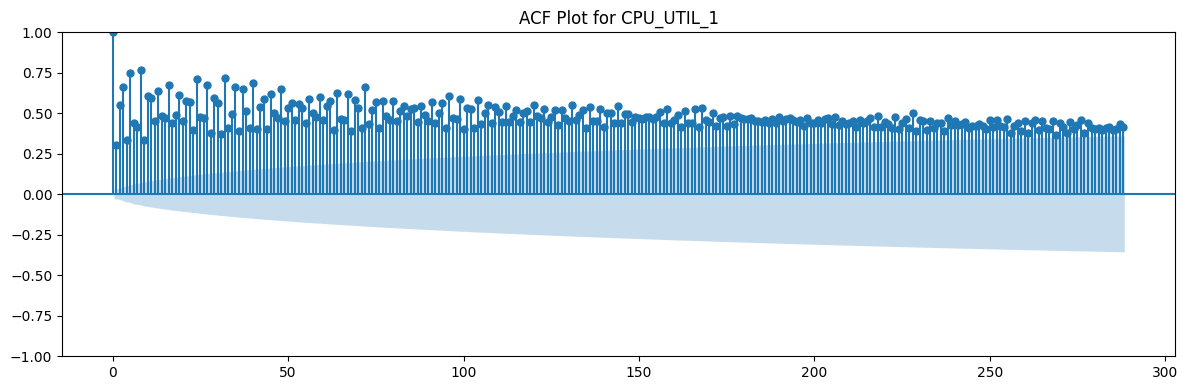

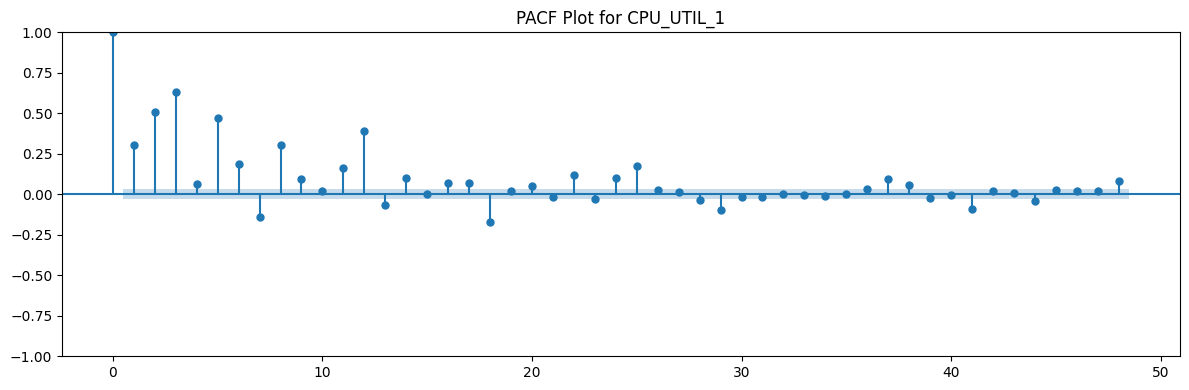

In [54]:
eda_3(dataset_name=dataset_name, df=dataframe, acf_lags=288, pacf_lags=48)

Characteristics:
- ACF is strongly positive for a long range of lags, indicating strong persistence and suggesting the series does not resemble white noise.
- PACF has some significant initial lags (strongest at 20 minutes lagged), but this decays quickly,
- Strong long-range persistence but short-term lags should be useful for prediction.

### Stationarity

In [55]:
def difference_series(df: pd.DataFrame, n_differences: int = 1, value_col: str = 'value') -> pd.DataFrame:
    if n_differences < 1:
        raise ValueError('n_differences must be at least 1')
    
    if value_col not in df.columns:
        raise ValueError(f'DataFrame is missing required column: {value_col}')

    df = df.copy()
    series = df[value_col].astype(float)

    for _ in range(n_differences):
        series = series.diff()

    df[value_col] = series
    return df


def eda_4(
    dataset_name: str,
    df: pd.DataFrame,
    anomaly_windows: List[Tuple[pd.Timestamp, pd.Timestamp]],
    sampling_interval: pd.Timedelta | None,
    make_stationary: Callable[[pd.DataFrame], pd.DataFrame] | None = None
) -> None:
    print_banner(dataset_name=dataset_name)

    if make_stationary is not None:
        df_stationary = make_stationary(df)
    else:
        df_stationary = df.copy()

    plot_series(df=df_stationary, anomaly_windows=anomaly_windows, title=f'Time Series Plot for {dataset_name} (Stationary Process Applied)')

    adf_test(df=df_stationary, value_col='value', should_print=True)
    fast_fourier_transform_estimation(df=df, value_col='value', time_col='timestamp', sampling_interval=sampling_interval, should_plot=True)

######################################################################################################################################################
Dataset CPU_UTIL_1 Analysis
######################################################################################################################################################


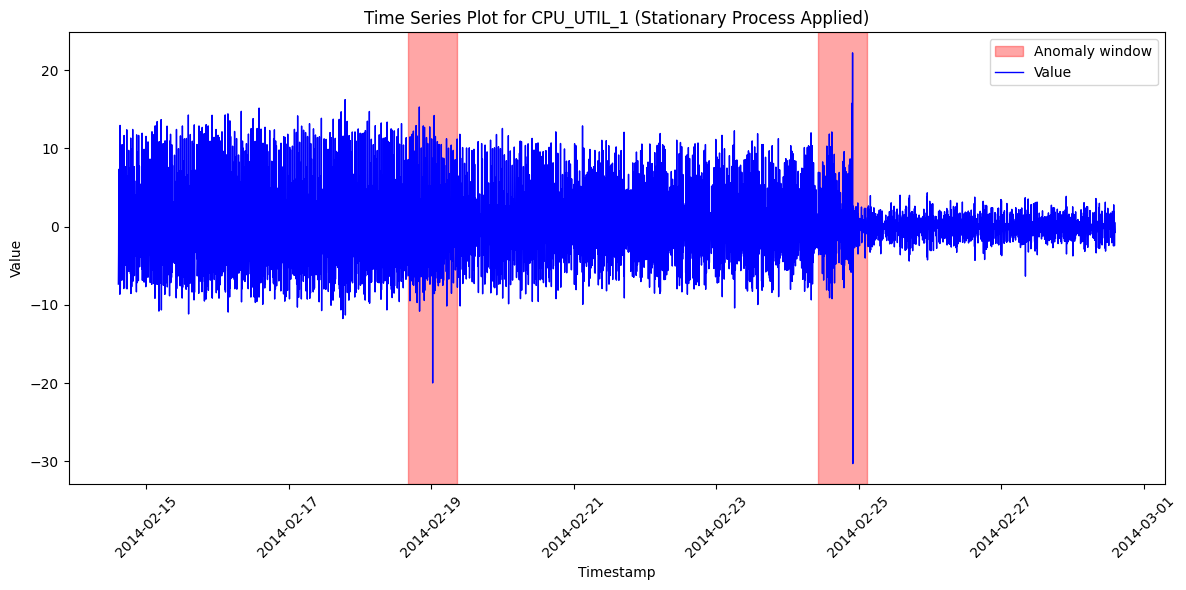

Property                        Value
-------------------------  ----------
adf_statistic               -19.2911
adf_p_value                   0
adf_used_lag                 27
adf_n_obs                  4003
adf_critical_value_1pct      -3.43198
adf_critical_value_5pct      -2.86226
adf_critical_value_10pct     -2.56715
adf_is_stationary_at_5pct     1


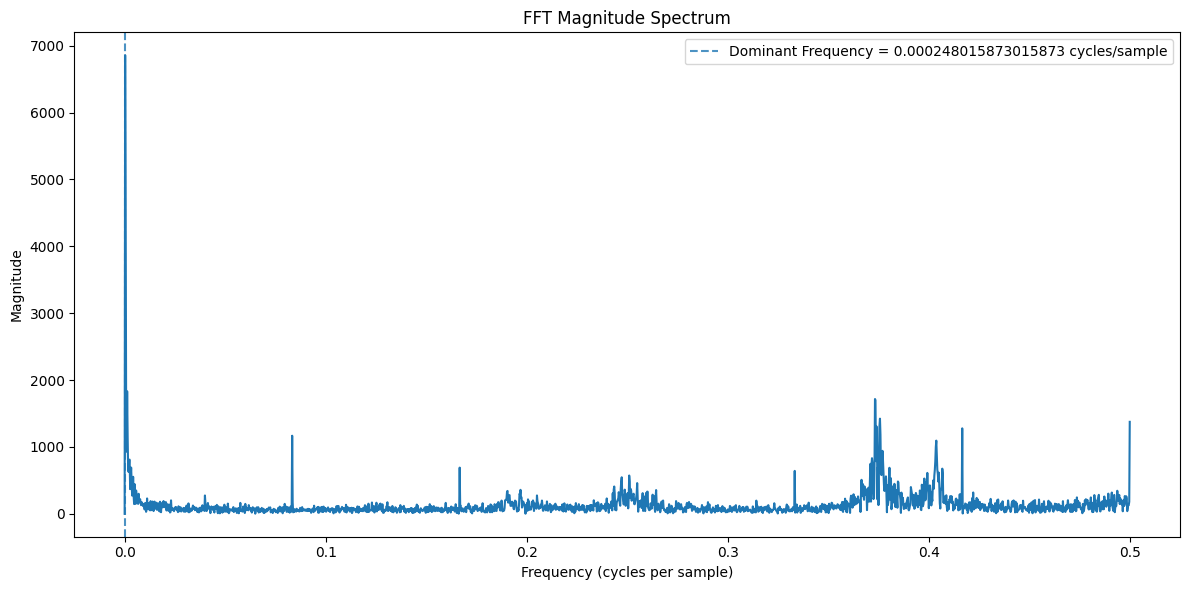

Property                       Value
-----------------------------  --------------------
dominant_frequency_per_sample  0.000248015873015873
dominant_period_in_samples     4032.0
dominant_period_timedelta      14 days 00:00:00
sampling_interval              0 days 00:05:00
n_used_points                  4032


In [56]:
eda_4(dataset_name=dataset_name, df=dataframe, anomaly_windows=anomaly_windows, sampling_interval=None, make_stationary=lambda df: difference_series(df=df, n_differences=1))

Characteristics:
- ADF result points towards the series being stationary after the differencing transformation.
- FFT points towards peaks at ~0.08 (period ~ 1 hour), ~0.37 (period ~ 14 minutes), ~0.5 (period ~ 10 minutes), which could be possible candidates for window size W, and also for prediction horizon H.

The analysis above should be replicated for the other files to identify further characteristics prior to model selection.